# Deep Learning Image Preprocessing

This notebook prepares common image inputs for future ViT and ResNet experiments.

Current goals:


1. Resample every `img.nii.gz` and `label.nii.gz` to `[2, 2, 2] mm`.
2. Generate a tumor bounding-box mask from the resampled label.
3. Save a summary table of resampled image shapes and bounding-box shapes.、
4. n4 bias correction


```


In [2]:
import sys
sys.path.append('/host/d/Github/')

import os
import numpy as np
import pandas as pd
import nibabel as nb

import Osteosarcoma.Data_processing as Data_processing
import Osteosarcoma.Build_lists.Build_list as Build_list

### Step 0: imports and settings


In [3]:

# ============================================================
# Paths
# ============================================================

patient_list_file = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set123.xlsx'
original_data_root = '/host/e/D/Data/Habitats/Jishuitan/original_data'
resampled_data_root = '/host/e/D/Data/Habitats/Jishuitan/resampled_data_new'
patient_list_out_dir = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists'

os.makedirs(resampled_data_root, exist_ok=True)
os.makedirs(patient_list_out_dir, exist_ok=True)


# ============================================================
# Resampling and bbox settings
# ============================================================

# We use anisotropic spacing here because the original data usually has
# high in-plane resolution and thick slices. This is a practical DL
# preprocessing spacing, not the radiomics [1,1,1] setting.
target_in_plane_resolution_mm = 1.0
target_slice_thickness_mm = 3.0

# Interpolation order:
# image: continuous intensity -> linear interpolation
# label: discrete mask -> nearest-neighbor interpolation
image_resample_order = 1
label_resample_order = 0

# Bounding box buffer is in voxel units after resampling to [1,1,3] mm.
# The user requested xy buffer first, no z buffer.
buffer_x = 5
buffer_y = 5
buffer_z = 0

# Resume switches. Set False here because we are regenerating [1,1,3] outputs
# over the previous resampled_data results.
skip_existing_resampled = False
skip_existing_bbox = False


build = Build_list.Build(patient_list_file)
batch_list, patient_set_list, patient_index_list, label_list, image_path_list, mask_path_list = build.__build__()

print('Number of cases to process:', len(patient_index_list))
print('Example image:', image_path_list[0])
print('Example mask :', mask_path_list[0])


Number of cases to process: 351
Example image: /host/e/D/Data/Habitats/Jishuitan/original_data/set_1/1/img.nii.gz
Example mask : /host/e/D/Data/Habitats/Jishuitan/original_data/set_1/1/label.nii.gz


### Step 1: resample image and label to `[1,1,3] mm`

For each case, save:

```text
resampled_data/{Patient_set}/{Patient_index}/img.nii.gz
resampled_data/{Patient_set}/{Patient_index}/label.nii.gz
```

Image and label are resampled separately but should end with the same shape. Label is binarized after nearest-neighbor resampling.


In [4]:
# ============================================================
# Step 1: resample image and label to [2,2,2] mm
# ============================================================

resample_rows = []
resample_done_count = 0
resample_skip_count = 0
resample_error_count = 0

for i in range(0, len(patient_index_list)):
    patient_set = str(patient_set_list[i])
    patient_index = str(patient_index_list[i])
    img_file = image_path_list[i]
    label_file = mask_path_list[i]

    print()
    print('============================================================')
    print('Step 1 resampling:', patient_set, patient_index, 'i =', i)

    save_folder = os.path.join(resampled_data_root, patient_set, patient_index)
    os.makedirs(save_folder, exist_ok=True)

    out_img = os.path.join(save_folder, 'img.nii.gz')
    out_label = os.path.join(save_folder, 'label.nii.gz')

    if os.path.exists(out_img):
        print('  Resampled image already exists, skipping:', out_img)
        continue

    row = {
        'Patient_set': patient_set,
        'Patient_index': patient_index,
        'Image_filepath_original': img_file,
        'Mask_filepath_original': label_file,
        'Image_filepath_resampled': out_img,
        'Mask_filepath_resampled': out_label,
    }

    if skip_existing_resampled and os.path.exists(out_img) and os.path.exists(out_label):
        print('  Resampled image and label already exist. Skipping.')
        resample_skip_count += 1
        try:
            img_nii_existing = nb.load(out_img)
            label_nii_existing = nb.load(out_label)
            row.update({
                'resampled_x_shape': img_nii_existing.shape[0],
                'resampled_y_shape': img_nii_existing.shape[1],
                'resampled_z_shape': img_nii_existing.shape[2],
                'resampled_dx': img_nii_existing.header.get_zooms()[0],
                'resampled_dy': img_nii_existing.header.get_zooms()[1],
                'resampled_dz': img_nii_existing.header.get_zooms()[2],
                'label_shape_matches_image': img_nii_existing.shape == label_nii_existing.shape,
                'status': 'skipped_existing',
                'error': '',
            })
        except Exception as e:
            row.update({'status': 'skipped_existing_but_read_failed', 'error': repr(e)})
        resample_rows.append(row)
        continue

    try:
        img_nii = nb.load(img_file)
        label_nii = nb.load(label_file)

        original_img_shape = img_nii.shape[:3]
        original_label_shape = label_nii.shape[:3]
        original_spacing = img_nii.header.get_zooms()[:3]

        image_data = img_nii.get_fdata()
        image_cval = float(np.nanmin(image_data))

        # Resample image intensity with linear interpolation.
        new_img_nii = Data_processing.resample_nifti(
            img_nii,
            order=image_resample_order,
            mode='constant',
            cval=image_cval,
            in_plane_resolution_mm=target_in_plane_resolution_mm,
            slice_thickness_mm=target_slice_thickness_mm,
        )
        nb.save(new_img_nii, out_img)

        # Resample label with nearest-neighbor interpolation.
        new_label_nii = Data_processing.resample_nifti(
            label_nii,
            order=label_resample_order,
            mode='constant',
            cval=0,
            in_plane_resolution_mm=target_in_plane_resolution_mm,
            slice_thickness_mm=target_slice_thickness_mm,
        )

        # Make sure label remains binary after resampling.
        label_arr = new_label_nii.get_fdata()
        label_arr = (label_arr > 0.5).astype(np.uint8)
        new_label_nii = nb.Nifti1Image(
            label_arr,
            affine=new_label_nii.affine,
            header=new_label_nii.header,
        )
        new_label_nii.header.set_data_dtype(np.uint8)
        nb.save(new_label_nii, out_label)

        if new_img_nii.shape != new_label_nii.shape:
            print('  WARNING: image/label shape mismatch after resampling:', new_img_nii.shape, new_label_nii.shape)


        row.update({
            'original_x_shape': original_img_shape[0],
            'original_y_shape': original_img_shape[1],
            'original_z_shape': original_img_shape[2],
            'original_label_x_shape': original_label_shape[0],
            'original_label_y_shape': original_label_shape[1],
            'original_label_z_shape': original_label_shape[2],
            'original_dx': original_spacing[0],
            'original_dy': original_spacing[1],
            'original_dz': original_spacing[2],
            'resampled_x_shape': new_img_nii.shape[0],
            'resampled_y_shape': new_img_nii.shape[1],
            'resampled_z_shape': new_img_nii.shape[2],
            'resampled_dx': new_img_nii.header.get_zooms()[0],
            'resampled_dy': new_img_nii.header.get_zooms()[1],
            'resampled_dz': new_img_nii.header.get_zooms()[2],
            'label_shape_matches_image': new_img_nii.shape == new_label_nii.shape,
            'status': 'done',
            'error': '',
        })

        resample_done_count += 1
        print('  Saved:', out_img)
        print('  Saved:', out_label)
        print('  Resampled shape:', new_img_nii.shape, 'spacing:', new_img_nii.header.get_zooms()[:3])

    except Exception as e:
        resample_error_count += 1
        row.update({'status': 'failed', 'error': repr(e)})
        print('  ERROR:', repr(e))

    resample_rows.append(row)

print()
print('============================================================')
print('Step 1 finished')
print('  done:', resample_done_count)
print('  skipped existing:', resample_skip_count)
print('  failed:', resample_error_count)



Step 1 resampling: set_1 1 i = 0
  Resampled image already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/1/img.nii.gz

Step 1 resampling: set_1 5 i = 1
  Resampled image already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/5/img.nii.gz

Step 1 resampling: set_1 7 i = 2
  Resampled image already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/7/img.nii.gz

Step 1 resampling: set_1 8 i = 3
  Resampled image already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/8/img.nii.gz

Step 1 resampling: set_1 11 i = 4
  Resampled image already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/11/img.nii.gz

Step 1 resampling: set_1 15 i = 5
  Resampled image already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/15/img.nii.gz

Step 1 resampling: set_1 18 i = 6
  Resampled image already exists, skipping: /host/e/D/Data/Ha

### Step 2: create tumor bounding-box mask from resampled label

For each resampled label, find all tumor voxels and create a rectangular box mask.

Current buffer:

```text
x/y: ±5 voxels
z:   ±0 voxels
```

Save:

```text
resampled_data/{Patient_set}/{Patient_index}/bbox_mask.nii.gz
```


In [5]:
# ============================================================
# Step 2: create tumor bounding-box mask from resampled label
# ============================================================

bbox_done_count = 0
bbox_skip_count = 0
bbox_error_count = 0

for i in range(0, len(patient_index_list)):
    patient_set = str(patient_set_list[i])
    patient_index = str(patient_index_list[i])

    print()
    print('============================================================')
    print('Step 2 bbox:', patient_set, patient_index, 'i =', i)

    save_folder = os.path.join(resampled_data_root, patient_set, patient_index)
    resampled_img_path = os.path.join(save_folder, 'img.nii.gz')
    resampled_label_path = os.path.join(save_folder, 'label.nii.gz')
    bbox_mask_path = os.path.join(save_folder, 'bbox_mask.nii.gz')

    if os.path.exists(bbox_mask_path):
        print('  Bbox mask already exists, skipping:', bbox_mask_path)
        bbox_skip_count += 1
        continue

    if not os.path.exists(resampled_img_path):
        bbox_error_count += 1
        print('  ERROR: resampled image not found:', resampled_img_path)
        continue

    if not os.path.exists(resampled_label_path):
        bbox_error_count += 1
        print('  ERROR: resampled label not found:', resampled_label_path)
        continue

    if skip_existing_bbox and os.path.exists(bbox_mask_path):
        print('  Bbox mask already exists. Skipping.')
        bbox_skip_count += 1
        continue

    try:
        img_nii = nb.load(resampled_img_path)
        label_nii = nb.load(resampled_label_path)
        label_arr = (label_nii.get_fdata() > 0.5).astype(np.uint8)

        tumor_voxel_num = int(np.sum(label_arr > 0))
        if tumor_voxel_num == 0:
            raise RuntimeError('no tumor voxels found in resampled label')

        # Data_processing.bbox3d returns a binary bbox mask and inclusive bounds.
        bbox_arr, x0, x1, y0, y1, z0, z1 = Data_processing.bbox3d(
            label_arr,
            buffer_x=buffer_x,
            buffer_y=buffer_y,
            buffer_z=buffer_z,
        )

        # Save full-size bbox mask.
        bbox_nii = nb.Nifti1Image(
            bbox_arr.astype(np.uint8),
            affine=label_nii.affine,
            header=label_nii.header,
        )
        bbox_nii.header.set_data_dtype(np.uint8)
        nb.save(bbox_nii, bbox_mask_path)


        bbox_x_shape = int(x1 - x0 + 1)
        bbox_y_shape = int(y1 - y0 + 1)
        bbox_z_shape = int(z1 - z0 + 1)

    except Exception as e:
        bbox_error_count += 1
        print('  ERROR:', repr(e))





Step 2 bbox: set_1 1 i = 0
  Bbox mask already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/1/bbox_mask.nii.gz

Step 2 bbox: set_1 5 i = 1
  Bbox mask already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/5/bbox_mask.nii.gz

Step 2 bbox: set_1 7 i = 2
  Bbox mask already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/7/bbox_mask.nii.gz

Step 2 bbox: set_1 8 i = 3
  Bbox mask already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/8/bbox_mask.nii.gz

Step 2 bbox: set_1 11 i = 4
  Bbox mask already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/11/bbox_mask.nii.gz

Step 2 bbox: set_1 15 i = 5
  Bbox mask already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/15/bbox_mask.nii.gz

Step 2 bbox: set_1 18 i = 6
  Bbox mask already exists, skipping: /host/e/D/Data/Habitats/Jishuitan/resampled_data_new/set_1/18/bbo

### Step 3: summarize resampled image shapes and bounding-box shapes

This table helps decide the later uniform input size for ViT / ResNet.

Save:

```text
/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_resampled_bbox_1x1x3.xlsx
```


In [7]:
# ============================================================
# Step 3: summarize original / resampled / bbox image information
# ============================================================

summary_rows = []
summary_error_count = 0

for i in range(0, len(patient_index_list)):
    patient_set = str(patient_set_list[i])
    patient_index = str(patient_index_list[i])

    print()
    print('============================================================')
    print('Step 3 summary:', patient_set, patient_index, 'i =', i)

    save_folder = os.path.join(resampled_data_root, patient_set, patient_index)

    original_img_path = image_path_list[i]
    original_label_path = mask_path_list[i]
    resampled_img_path = os.path.join(save_folder, 'img.nii.gz')
    resampled_label_path = os.path.join(save_folder, 'label.nii.gz')
    bbox_mask_path = os.path.join(save_folder, 'bbox_mask.nii.gz')

    try:
        original_img_nii = nb.load(original_img_path)
        original_label_nii = nb.load(original_label_path)
        resampled_img_nii = nb.load(resampled_img_path)
        resampled_label_nii = nb.load(resampled_label_path)

        original_dx, original_dy, original_dz = original_img_nii.header.get_zooms()[:3]
        resampled_dx, resampled_dy, resampled_dz = resampled_img_nii.header.get_zooms()[:3]

        resampled_img_arr = resampled_img_nii.get_fdata()

        bbox_data = nb.load(bbox_mask_path).get_fdata()
        # 找到pixel=1的pixels坐标
        coords = np.where(bbox_data > 0)
        x_min, x_max = np.min(coords[0]), np.max(coords[0])
        y_min, y_max = np.min(coords[1]), np.max(coords[1])
        z_min, z_max = np.min(coords[2]), np.max(coords[2])

        # get bbox intensity min/max, median, 95 percentile, 99 percentile
        a = np.zeros(resampled_img_arr.shape)
        a[bbox_data > 0] = resampled_img_arr[bbox_data > 0]
        bbox_intensity_min = float(np.min(a[a > 0]))
        bbox_intensity_max = float(np.max(a))
        bbox_intensity_median = float(np.median(a[a > 0]))
        bbox_intensity_95 = float(np.percentile(a[a > 0], 95))
        bbox_intensity_99 = float(np.percentile(a[a > 0], 99))

        row = {
            'Patient_set': patient_set,
            'Patient_index': patient_index,
            'Image_filepath_original': original_img_path,
            'Mask_filepath_original': original_label_path,
            'Image_filepath_resampled': resampled_img_path,
            'Mask_filepath_resampled': resampled_label_path,
            'Bbox_mask_filepath': bbox_mask_path,
  
            'original_x_shape': int(original_img_nii.shape[0]),
            'original_y_shape': int(original_img_nii.shape[1]),
            'original_z_shape': int(original_img_nii.shape[2]),
            'original_dx': float(original_dx),
            'original_dy': float(original_dy),
            'original_dz': float(original_dz),
            'resampled_x_shape': int(resampled_img_nii.shape[0]),
            'resampled_y_shape': int(resampled_img_nii.shape[1]),
            'resampled_z_shape': int(resampled_img_nii.shape[2]),
            'resampled_dx': float(resampled_dx),
            'resampled_dy': float(resampled_dy),
            'resampled_dz': float(resampled_dz),
            'bbox_x_shape': x_max - x_min + 1,
            'bbox_y_shape': y_max - y_min + 1,
            'bbox_z_shape': z_max - z_min + 1,
            'bbox_intensity_min': bbox_intensity_min,
            'bbox_intensity_max': bbox_intensity_max,
            'bbox_intensity_median': bbox_intensity_median,
            'bbox_intensity_95': bbox_intensity_95,
            'bbox_intensity_99': bbox_intensity_99, 
        }

        summary_rows.append(row)


    except Exception as e:
        summary_error_count += 1
        print('  ERROR:', repr(e))

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(
    patient_list_out_dir,
    'image_label_info_set122_resampled_bbox_1x1x3.xlsx',
)
summary_df.to_excel(summary_path, index=False)





Step 3 summary: set_1 1 i = 0

Step 3 summary: set_1 5 i = 1

Step 3 summary: set_1 7 i = 2

Step 3 summary: set_1 8 i = 3

Step 3 summary: set_1 11 i = 4

Step 3 summary: set_1 15 i = 5

Step 3 summary: set_1 18 i = 6

Step 3 summary: set_1 19 i = 7

Step 3 summary: set_1 20 i = 8

Step 3 summary: set_1 21 i = 9

Step 3 summary: set_1 22 i = 10

Step 3 summary: set_1 23 i = 11

Step 3 summary: set_1 24 i = 12

Step 3 summary: set_1 26 i = 13

Step 3 summary: set_1 28 i = 14

Step 3 summary: set_1 29 i = 15

Step 3 summary: set_1 30 i = 16

Step 3 summary: set_1 33 i = 17

Step 3 summary: set_1 34 i = 18

Step 3 summary: set_1 36 i = 19

Step 3 summary: set_1 38 i = 20

Step 3 summary: set_1 40 i = 21

Step 3 summary: set_1 41 i = 22

Step 3 summary: set_1 42 i = 23

Step 3 summary: set_1 43 i = 24

Step 3 summary: set_1 44 i = 25

Step 3 summary: set_1 46 i = 26

Step 3 summary: set_1 48 i = 27

Step 3 summary: set_1 50 i = 28

Step 3 summary: set_1 51 i = 29

Step 3 summary: set_1 5

### manually check the intensity distribution in the tumor region

Patient_set: set_1 Patient_index: 11
  intensity range in tumor region: (0.0, 737.5271690425654) median: 194.9123018361188 75 percentile: 282.7926045095026 95 percentile: 446.97712350635277


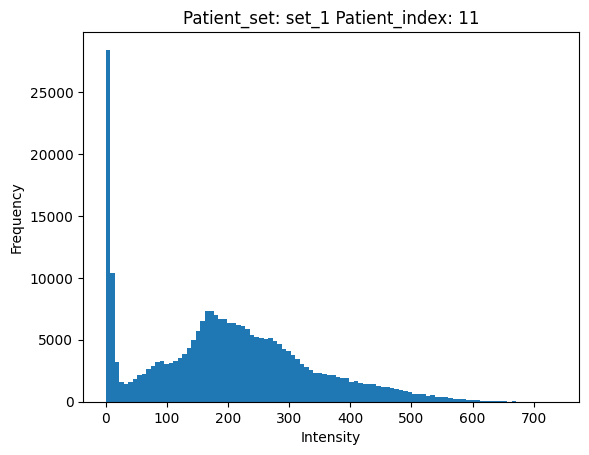

In [8]:
import matplotlib.pyplot as plt
for i in range(4,5):# len(patient_index_list)):
    patient_set = str(patient_set_list[i])
    patient_index = str(patient_index_list[i])
    img = nb.load(os.path.join(resampled_data_root, patient_set, patient_index, 'img.nii.gz')).get_fdata()
    label = nb.load(os.path.join(resampled_data_root, patient_set, patient_index, 'bbox_mask.nii.gz')).get_fdata()

    a = np.zeros_like(img)
    a[label > 0] = img[label > 0]

    # find out the range, median, 75 percentile, 95 percentile of a[label>0]
    print('Patient_set:', patient_set, 'Patient_index:', patient_index)
    I_range = (float(np.min(a[label > 0])), float(np.max(a[label > 0])))
    median = float(np.median(a[label > 0]))
    percentile_75 = float(np.percentile(a[label > 0], 75))
    percentile_95 = float(np.percentile(a[label > 0], 95))
    print('  intensity range in tumor region:', I_range, 'median:', median, '75 percentile:', percentile_75, '95 percentile:', percentile_95)

    # plot a histogram of a[label>0] with 100 bins between I_range[0] and I_range[1]
    plt.figure()
    plt.hist(a[label > 0].flatten(), bins=100, range=I_range)
    plt.title(f'Patient_set: {patient_set} Patient_index: {patient_index}')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.show()

## N4 bias correction

In [ ]:
patient_list_file = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12.xlsx'

build = Build_list.Build(patient_list_file)
batch_list, patient_set_list, patient_index_list, label_list, image_path_list, mask_path_list = build.__build__()

print('Number of cases to process:', len(patient_index_list))
print('Example image:', image_path_list[0])
print('Example mask :', mask_path_list[0])


In [ ]:
import os
import SimpleITK as sitk

resampled_data_root = '/host/e/D/Data/Habitats/Jishuitan/resampled_data'

# ============================================================
# N4 settings
# ============================================================

n4_max_iterations = [50, 50, 30, 20]


# ============================================================
# Run all cases
# ============================================================

for i in range(0, len(patient_index_list)):
    patient_set = patient_set_list[i]
    patient_index = patient_index_list[i]

    print("\n============================================================")
    print("Processing patient set:", patient_set, "patient index:", patient_index, " i is ", i)

    case_resampled_dir = os.path.join(
        resampled_data_root,
        str(patient_set),
        str(patient_index),
    )

    img_path = os.path.join(case_resampled_dir, "img.nii.gz")
    img_n4_path = os.path.join(case_resampled_dir, "img_n4.nii.gz")

    if not os.path.isfile(img_path):
        print("  Resampled image not found. Skipping:", img_path)
        continue

    if os.path.isfile(img_n4_path):
        print("  N4 image already exists. Skipping:", img_n4_path)
        continue

    try:
        # ----------------------------------------------------
        # 1. Read image
        # ----------------------------------------------------
        img_sitk = sitk.ReadImage(img_path, sitk.sitkFloat32)

        # ----------------------------------------------------
        # 2. Build a simple foreground mask
        # ----------------------------------------------------
        mask_sitk = sitk.OtsuThreshold(img_sitk, 0, 1, 200)

        # ----------------------------------------------------
        # 3. Run N4 bias correction
        # ----------------------------------------------------
        corrector = sitk.N4BiasFieldCorrectionImageFilter()
        corrector.SetMaximumNumberOfIterations(n4_max_iterations)

        print("  Running N4...")
        img_n4_sitk = corrector.Execute(img_sitk, mask_sitk)

        # ----------------------------------------------------
        # 4. Save corrected image
        # ----------------------------------------------------
        sitk.WriteImage(img_n4_sitk, img_n4_path)

        print("  Saved:", img_n4_path)

    except Exception as e:
        print("  Failed:", str(e))